# 4 · Análises de resultados — o notebook central do trabalho

**O que é.** O ponto único onde as análises de resultados da dissertação nascem,
são conferidas e viram figura/tabela. Cada análise declara: a decisão que a
ampara, a fonte dos dados, e as ressalvas vigentes.

**Contrato (não editar sem ler):**
- **Corpus canônico (SÓ LEITURA):** `/Users/gmello/Documents/python_repos/mestrado/resultados_experimentos/`
  — estrutura `{algoritmo}/{problema}/{semente}/`, 7 camadas por célula
  (`CONTRATO_DE_DADOS.md`).
- **Métrica oficial:** `src/metrics.py` deste repo — normalização pela tabela
  S.5 congelada (D69), **IGD+ = endpoint primário (D70)**, HV com ref = 1,1 por
  coordenada, reference sets D72, guard executável `checa_regua`.
- **Regimes analisados em quadros separados (D70):** online (`exp_main`, ① ND
  acumulado) × offline (`exp_off`, endpoint = camada ⑦ `__final`, DI-13.9).
- **DDMOP7:** só HV (D102.4) e com **selo de régua PROVISÓRIA** (D102.3 — a
  fase 2 pooled pós-hoc substitui a régua e re-roda a §12).
- **Snapshot VIVO (17/08/2026):** a campanha ainda roda (vm1+vm5; reais
  pousando). Números daqui NÃO vão à prosa final sem recontagem no
  congelamento do corpus (§3 da lei da dissertação).
- **Ambiente:** executar com o `env_main`
  (`/Users/gmello/Documents/python_venvs/mestrado_experimentos_dissertacao`).
  Este notebook foi executado por um runner com esse python (o venv é pinado —
  D80 — e não recebe jupyter/ipykernel).


In [ ]:
import os, sys, glob, re, json, collections
for v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[v] = "1"
UA = "/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea"
CORPUS = "/Users/gmello/Documents/python_repos/mestrado/resultados_experimentos"
CACHE = os.path.join(UA, "data", "analysis_cache")
FIGDIR = "/Users/gmello/Documents/python_repos/mestrado/dissertacao/figures"
sys.path.insert(0, UA)
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from src import metrics
print("env:", sys.version.split()[0], "· numpy", np.__version__, "· pandas", pd.__version__)
print("endpoint primário:", metrics.PRIMARY_METRIC, "· HV ref =", metrics.HV_REF_COORD)

env: 3.11.9 · numpy 2.4.6 · pandas 2.3.3
endpoint primário: igd_plus · HV ref = 1.1


## §1 · Completude do corpus (o placar honesto)

**Objetivo.** Saber o que existe antes de medir qualquer coisa: quantas células
(algoritmo × problema × semente) pousaram, quantas faltam contra o grid, e a
anatomia dos arquivos por célula. Reproduz por código a conferência registrada
em `numeros_verificados §44` da dissertação.

In [ ]:
seeds = collections.Counter(); dist = collections.Counter(); abortadas = collections.Counter()
for a in sorted(os.listdir(CORPUS)):
    pa = os.path.join(CORPUS, a)
    if not os.path.isdir(pa) or a.startswith(("_", ".")): continue
    for p in sorted(os.listdir(pa)):
        pp = os.path.join(pa, p)
        if not os.path.isdir(pp) or p.startswith("."): continue
        for s in os.listdir(pp):
            ps = os.path.join(pp, s)
            if not os.path.isdir(ps) or s.startswith("."): continue
            n = sum(1 for f in os.listdir(ps) if not f.startswith(".") and os.path.isfile(os.path.join(ps, f)))
            seeds[(a, p)] += 1; dist[n] += 1
            if n <= 2: abortadas[(a, p)] += 1
tot = sum(seeds.values())
print(f"pastas de seed: {tot} · distribuição arquivos/seed: {dict(sorted(dist.items()))}")
print(f"abortadas (1-2 arquivos): {sum(abortadas.values())} — b1/DTLZ4 = {abortadas.get(('b1','DTLZ4'),0)}/30 (dacefit, D0) · c238 = {sum(v for (a,p),v in abortadas.items() if a=='c238')} (Infill_EIM, DEC-8)")
for pr in ("RE21", "ESTOQUE40", "DDMOP7"):
    print(f"  {pr}: {sum(v for (a,p),v in seeds.items() if p==pr)} seeds em disco (de 630 = 21 configs × 30)")
print("nota: 5 arquivos = célula OK com a camada ③ no bucket (uploaded_bucket_only, D54/D58);")
print("      8 arquivos = offline com a ⑦ __final; 1-2 = aborto precoce (categorias nomeadas nos laudos)")

pastas de seed: 16205 · distribuição arquivos/seed: {1: 99, 2: 16, 5: 3487, 6: 10353, 7: 1, 8: 2249}
abortadas (1-2 arquivos): 115 — b1/DTLZ4 = 30/30 (dacefit, D0) · c238 = 45 (Infill_EIM, DEC-8)
  RE21: 566 seeds em disco (de 630 = 21 configs × 30)
  ESTOQUE40: 324 seeds em disco (de 630 = 21 configs × 30)
  DDMOP7: 187 seeds em disco (de 630 = 21 configs × 30)
nota: 5 arquivos = célula OK com a camada ③ no bucket (uploaded_bucket_only, D54/D58);
      8 arquivos = offline com a ⑦ __final; 1-2 = aborto precoce (categorias nomeadas nos laudos)


## §2 · O gate da métrica (âncora D92)

**Objetivo.** Antes de publicar qualquer número, provar que a máquina de medir
está certa: o HV do front analítico do BBOB F1, normalizado pela régua S.5 com
ref 1,1, tem valor fechado `1,21 − 1/6 = 1,0433…`. Se este gate falhar, nada
abaixo vale.

In [ ]:
smoke = metrics.hv_smoke_bbob_f1()
sanity = metrics.hv_front_sanity_bbob_f1()
print(f"hv_smoke_bbob_f1 (ref 1,1) = {smoke:.4f}  (esperado {metrics.HV_SMOKE_BBOB_F1})")
print(f"hv_front_sanity  (ref 1,0) = {sanity:.4f}  (esperado {metrics.HV_SANITY_BBOB_F1})")
assert abs(smoke - metrics.HV_SMOKE_BBOB_F1) < 5e-4 and abs(sanity - metrics.HV_SANITY_BBOB_F1) < 5e-4
print("GATE D92: OK")

hv_smoke_bbob_f1 (ref 1,1) = 1.0433  (esperado 1.0433)
hv_front_sanity  (ref 1,0) = 0.8333  (esperado 0.8333)
GATE D92: OK


## §3 · Métricas de endpoint por célula

**Objetivo.** Para cada célula pousada, medir o resultado FINAL da busca:
- **online (`exp_main`):** o conjunto não-dominado de TODAS as avaliações
  reais da célula (camada ①) — o que o algoritmo de fato entregou dentro do
  orçamento `31D−1`;
- **offline (`exp_off`):** a camada ⑦ (`__final` — o não-dominado do modelo
  REAVALIADO na função verdadeira, DI-13.9). e103 sem ⑦ (669/669, escalação
  F30) fica registrado como `final_ausente`, não silenciado.

Cada conjunto passa por: `checa_regua` (guard da S.5) → filtro não-dominado →
normalização (D69) → IGD+ · HV · IGD · GD · spacing. DDMOP7: só HV (D102.4).
O cômputo completo (~16 mil células, ~8 processos) grava um CACHE datado; se o
cache existir, a célula abaixo o carrega em vez de recomputar.

In [ ]:
CSV = os.path.join(CACHE, "metricas_endpoint_snapshot_2026-08-17.csv")
if not os.path.exists(CSV):
    raise SystemExit("cache ausente — rode o cômputo completo (ver célula-fonte no repositório da sessão)")
df = pd.read_csv(CSV)
df["erro"] = df["erro"].fillna("")          # round-trip do CSV: "" vira NaN
df["selo"] = df["selo"].fillna("")
ok = df[df.erro == ""]
print(f"células no cache: {len(df)} · com métrica: {len(ok)} · sem: {len(df)-len(ok)}")
print("motivos (categoria):", df[df.erro != ""].erro.str.split(":").str[0].value_counts().to_dict())
print("seladas REGUA_PROVISORIA (DDMOP7, D102.3):", int((df.selo == "REGUA_PROVISORIA").sum()))

células no cache: 16202 · com métrica: 15268 · sem: 934
motivos (categoria): {'final_ausente': 826, 'real_ausente': 108}
seladas REGUA_PROVISORIA (DDMOP7, D102.3): 90


## §4 · As matrizes de desempenho (fig. 5.1 e 5.2 da dissertação)

**Objetivo.** O mapa-múndi do estudo: a mediana (sobre as sementes pousadas) do
**IGD+ final** (primária, D70) e do **HV final** por algoritmo × problema, no
regime online. Leitura:
- valores absolutos **não se comparam entre problemas** (SPEC L367) — por isso
  a cor é normalizada POR LINHA e serve para comparar algoritmos DENTRO de
  cada problema; verde = melhor nas duas matrizes (branco = pior);
- os 4 pisos sem surrogate ficam à direita da linha preta — a régua na frente
  da qual todo assistido é lido;
- número vermelho no canto = célula com menos de 30 sementes (snapshot);
  hachura = célula sem dado.

rank médio (IGD+, 25 sintéticos + RE21/ESTOQUE40; 1 = melhor):
qNEHVI         4.08
MMRAEA         4.41
θ-DEA-DP       5.31
K-RVEA         6.27
CLMEA          6.70
EIM            7.22
ParEGO         7.68
SMS-EMOA       8.04
NSGA-II        8.93
NSGA-III       9.56
EDN-ARMOEA    10.00
JES           10.68
PC-SAEA       10.81
CSEA          10.92
qPOTS         12.19
MOEA/D        13.41
LBN-MOBO      14.92
figuras 5.1 e 5.2 exportadas para /Users/gmello/Documents/python_repos/mestrado/dissertacao/figures


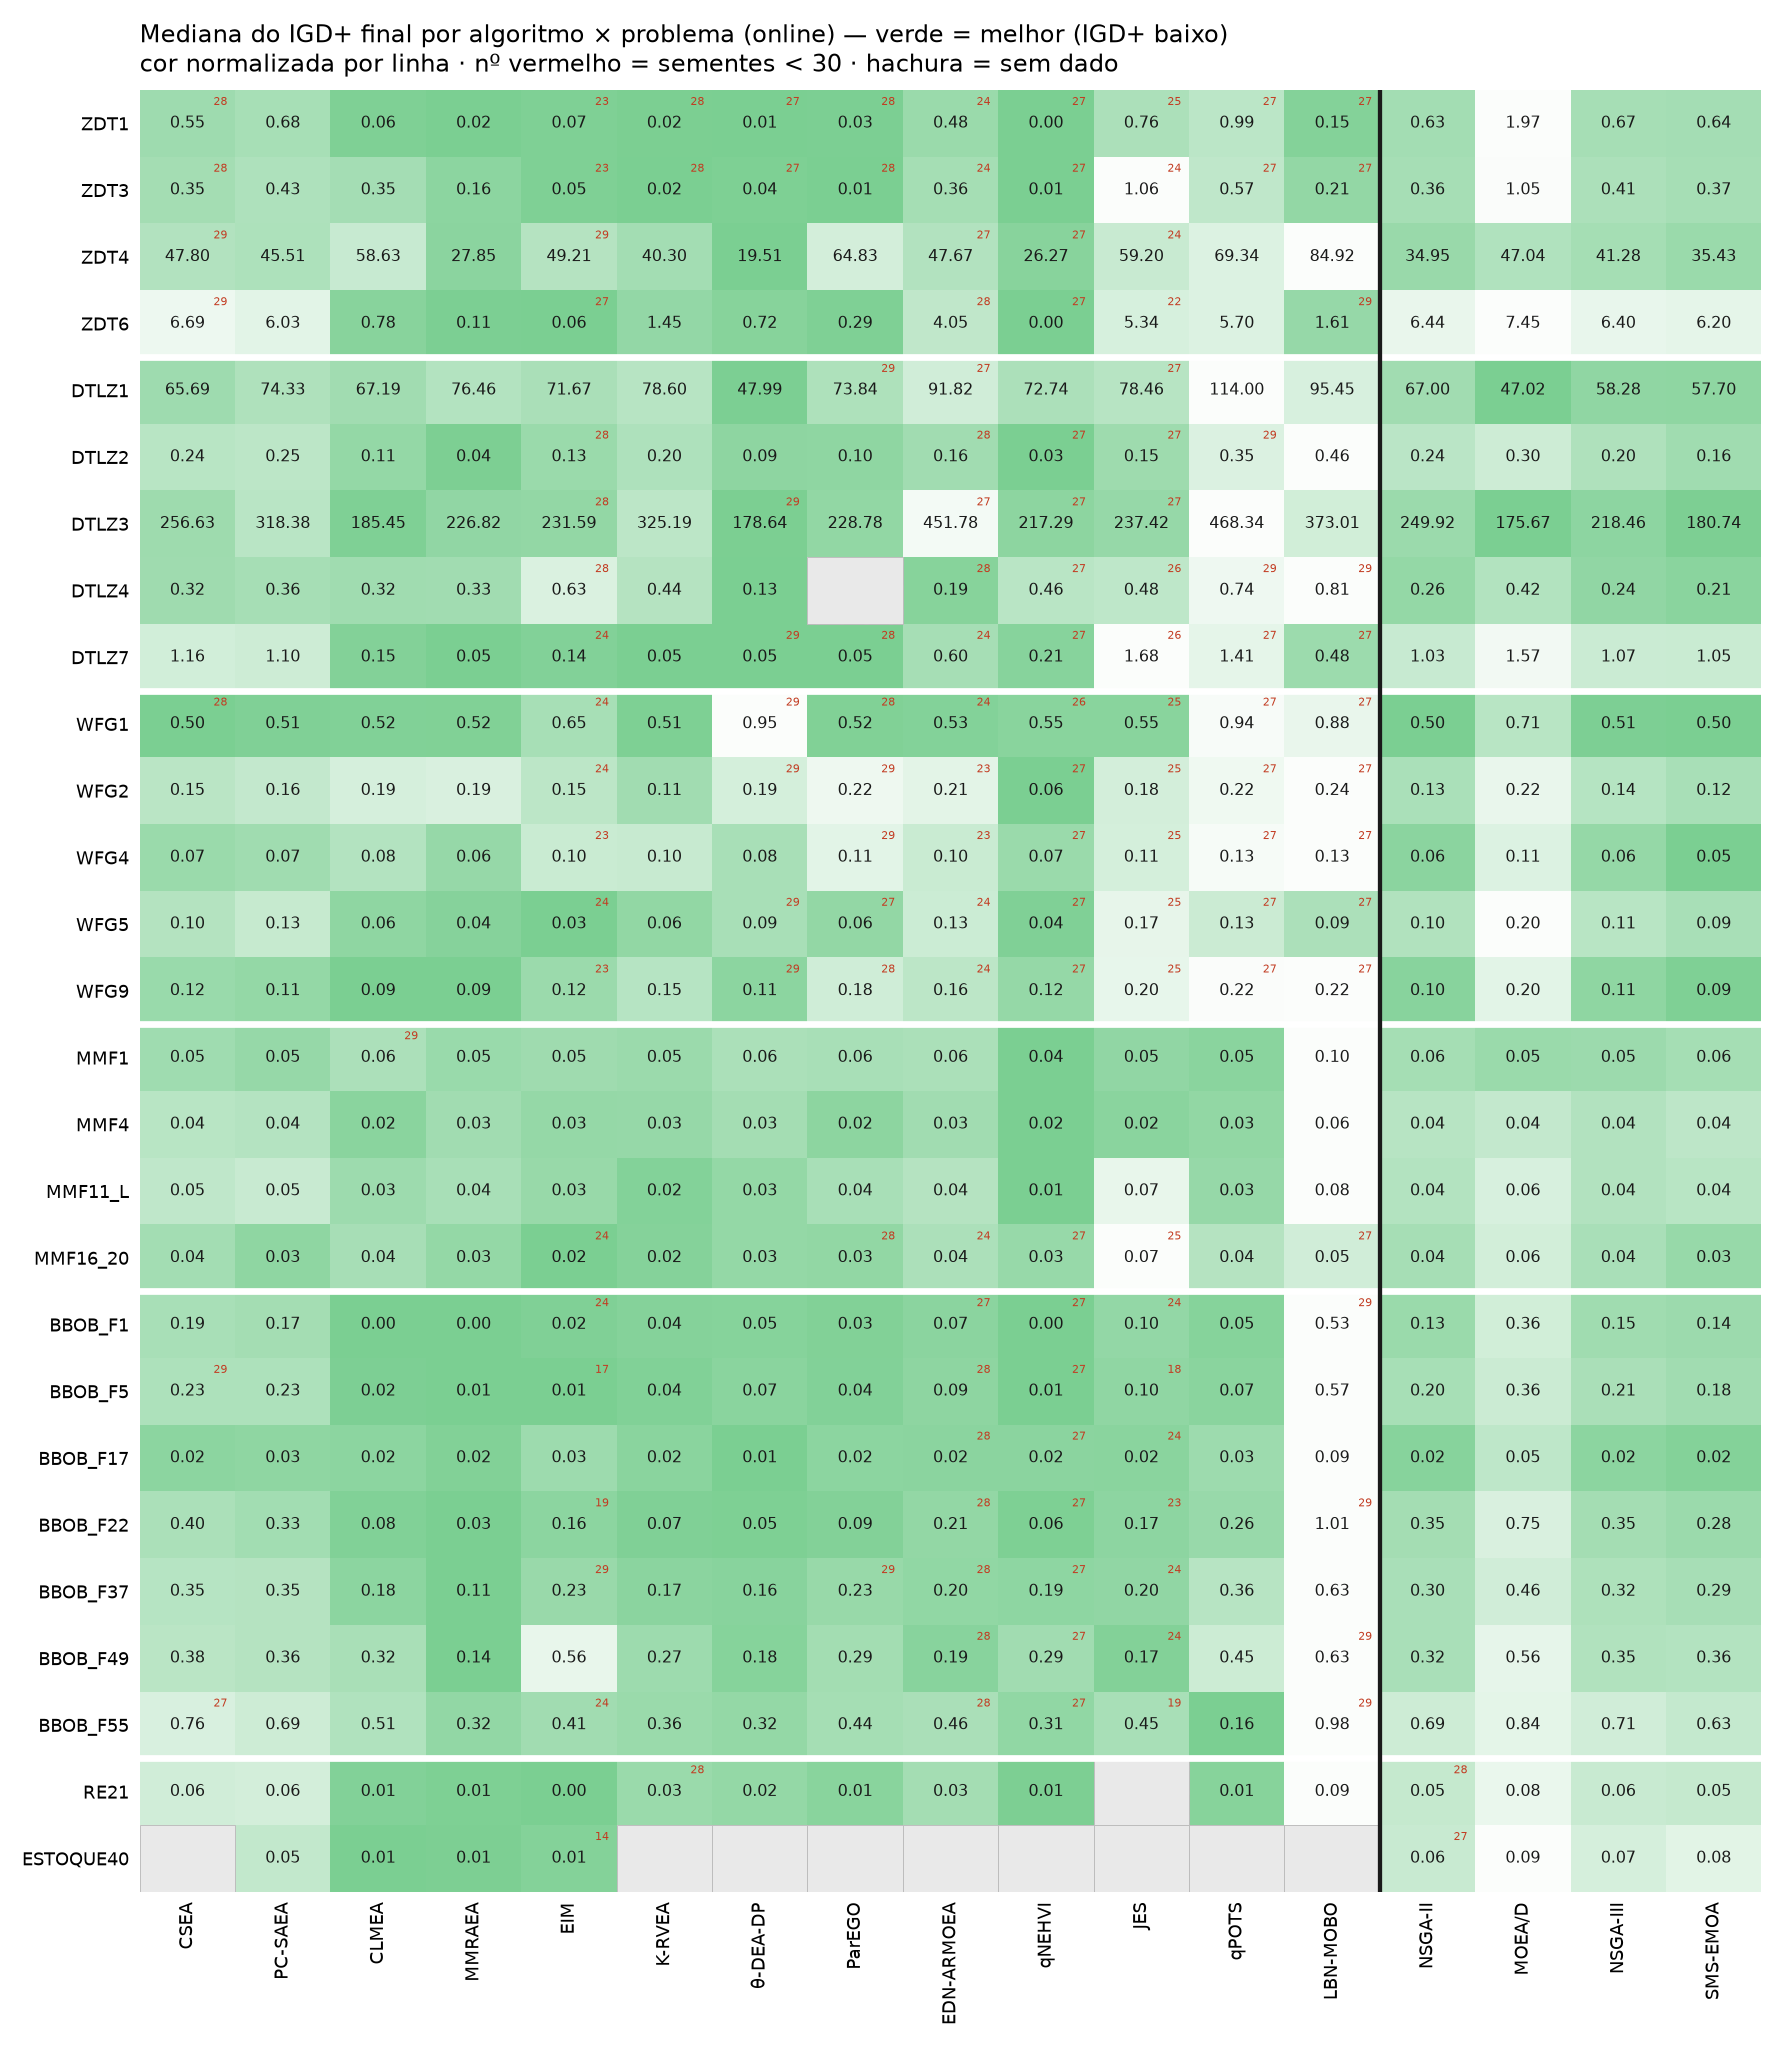

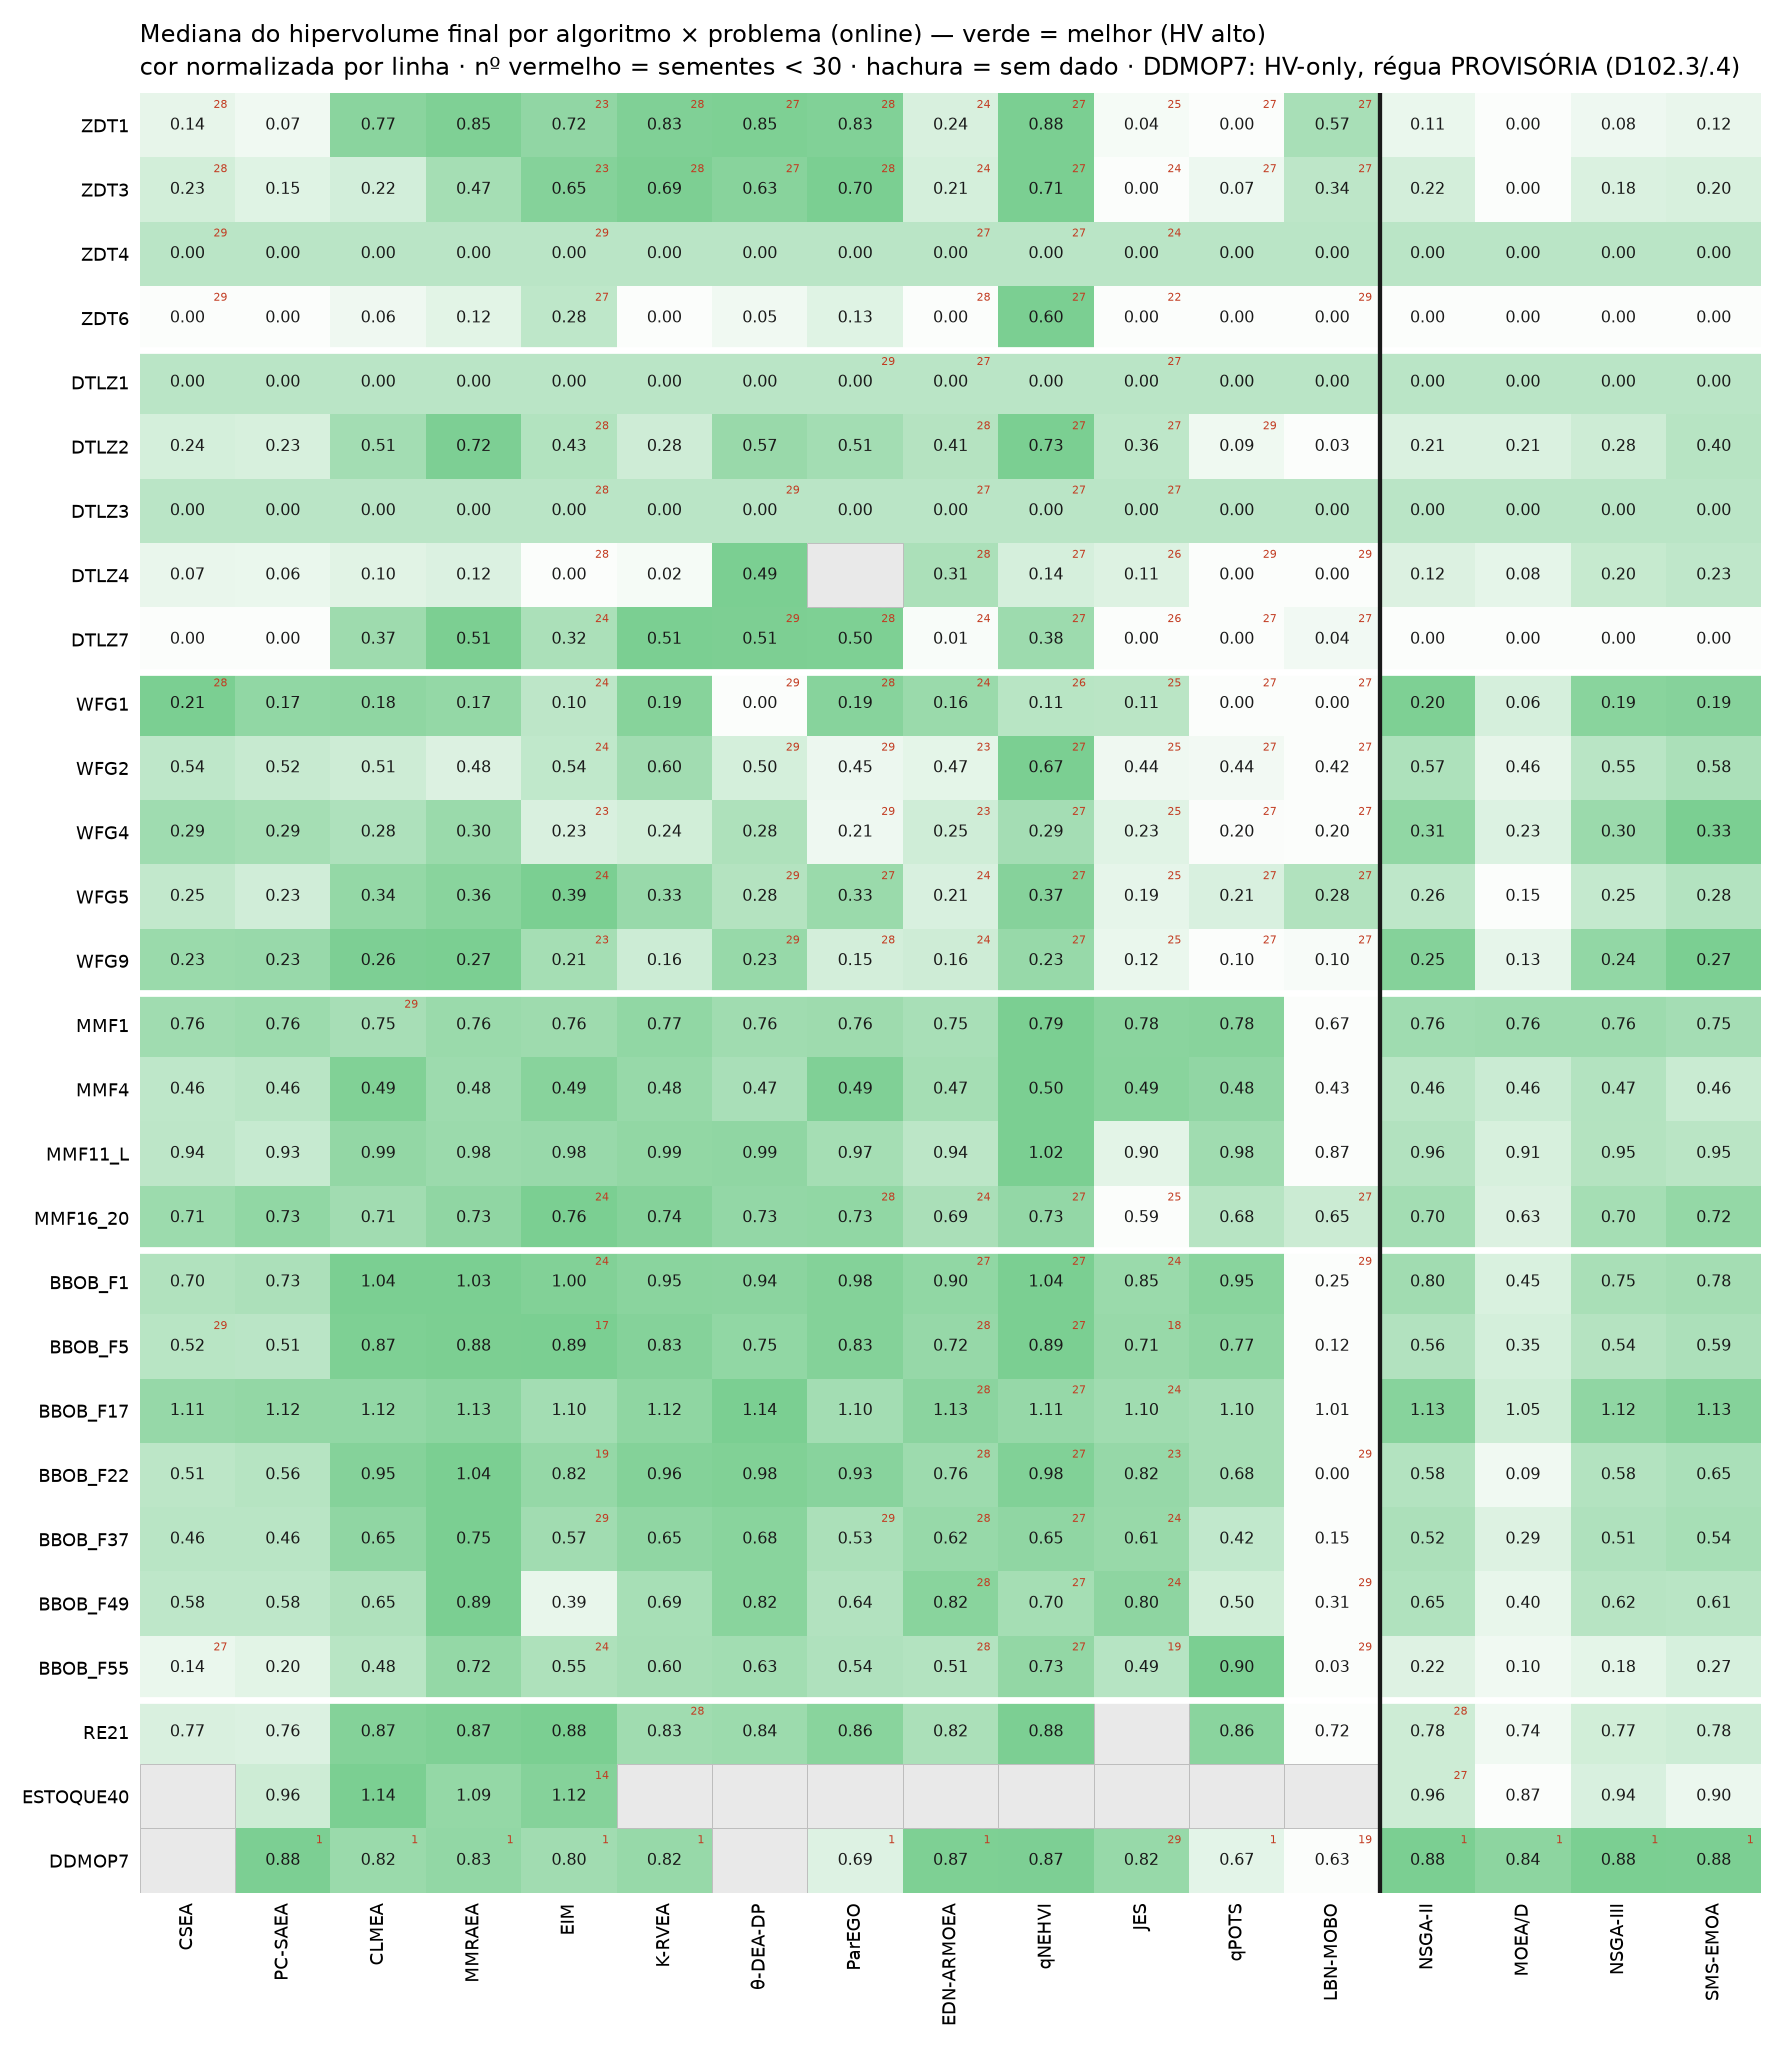

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

NOME = {"b1": "ParEGO", "b3": "K-RVEA", "b4": "CSEA", "c122": "θ-DEA-DP",
        "c141": "MMRAEA", "c149": "LBN-MOBO", "c154": "JES", "c217": "PC-SAEA",
        "c238": "EIM", "c262": "qNEHVI", "e7": "EDN-ARMOEA", "e74": "CLMEA",
        "e81": "qPOTS", "nsga2": "NSGA-II", "nsga3": "NSGA-III", "moead": "MOEA/D",
        "smsemoa": "SMS-EMOA", "b5m": "Prob-MOEA/D", "b5r": "Prob-RVEA",
        "e103": "IBEA-MS", "moead_media": "MOEA/D-média"}
ONLINE = ["b4", "c217", "e74", "c141", "c238", "b3", "c122", "b1", "e7",
          "c262", "c154", "e81", "c149", "nsga2", "moead", "nsga3", "smsemoa"]
PISO_DE = {"b4": "nsga2", "c217": "nsga2", "e74": "nsga2", "c141": "nsga2",
           "c238": "nsga2", "b3": "moead", "c122": "moead", "b1": "moead",
           "e7": "nsga3", "c262": "smsemoa"}
BANDA = ["c154", "e81", "c149"]
PISOS = ["nsga2", "moead", "nsga3", "smsemoa"]
OFFLINE = ["b5m", "b5r", "e103", "moead_media"]
PROBLEMAS = ["ZDT1", "ZDT3", "ZDT4", "ZDT6",
             "DTLZ1", "DTLZ2", "DTLZ3", "DTLZ4", "DTLZ7",
             "WFG1", "WFG2", "WFG4", "WFG5", "WFG9",
             "MMF1", "MMF4", "MMF11_L", "MMF16_20",
             "BBOB_F1", "BBOB_F5", "BBOB_F17", "BBOB_F22", "BBOB_F37",
             "BBOB_F49", "BBOB_F55", "RE21", "ESTOQUE40"]
SEPARA_APOS = {3, 8, 13, 17, 24}
VERDE = LinearSegmentedColormap.from_list("verde", ["#fbfdfb", "#7bcf92"])
DIVERG = LinearSegmentedColormap.from_list("div", ["#dfa07e", "#fbfbf9", "#7bcf92"])
on = ok[ok.exp == "main"]
off = ok[ok.exp == "off"]

def medianas(base, metrica, algs, problemas):
    med = pd.DataFrame(index=problemas, columns=algs, dtype=float)
    nse = pd.DataFrame(0, index=problemas, columns=algs, dtype=int)
    for a in algs:
        sub = base[base.alg == a]
        for p in problemas:
            v = sub[sub.problema == p][metrica].dropna()
            if len(v):
                med.loc[p, a] = float(v.median()); nse.loc[p, a] = len(v)
    return med, nse

def heat(ax, med, nse, cmap, invert, fmt=".2f", fs=5.4):
    vals = med.values.astype(float)
    C = np.full(vals.shape, np.nan)          # cor normalizada POR LINHA (SPEC L367)
    for i in range(vals.shape[0]):
        r, okm = vals[i], ~np.isnan(vals[i])
        if okm.sum() > 1 and np.nanmax(r) > np.nanmin(r):
            C[i, okm] = (r[okm] - np.nanmin(r)) / (np.nanmax(r) - np.nanmin(r))
        elif okm.any():
            C[i, okm] = 0.5
    if invert:
        C = 1.0 - C
    ax.imshow(np.ma.masked_invalid(C), cmap=cmap, aspect="auto", vmin=0, vmax=1)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            if np.isnan(vals[i, j]):
                ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, color="#e9e9e9",
                                           hatch="///", ec="#bbbbbb", lw=.3))
                continue
            ax.text(j, i, format(vals[i, j], fmt), ha="center", va="center",
                    fontsize=fs, color="#1a1a1a")
            if 0 < nse.iloc[i, j] < 30:
                ax.text(j + .42, i - .40, str(nse.iloc[i, j]), ha="right",
                        va="top", fontsize=3.6, color="#c23b21")
    ax.set_xticks(range(vals.shape[1]))
    ax.set_xticklabels([NOME[a] for a in med.columns], rotation=90, fontsize=6)
    ax.set_yticks(range(vals.shape[0]))
    ax.set_yticklabels(med.index, fontsize=6)
    for s in SEPARA_APOS:
        if s < vals.shape[0]:
            ax.axhline(s + .5, color="white", lw=2.2)
    npiso = sum(1 for a in med.columns if a in PISOS)
    if npiso:
        ax.axvline(len(med.columns) - npiso - .5, color="#1a1a1a", lw=1.4)
    ax.tick_params(length=0)
    [sp.set_visible(False) for sp in ax.spines.values()]

EMBED_PNG = []
for metrica, invert, titulo, fname, probs in [
    ("igd_plus", True,
     "Mediana do IGD+ final por algoritmo × problema (online) — verde = melhor (IGD+ baixo)",
     "fig51_matriz_igdplus", PROBLEMAS),
    ("hv", False,
     "Mediana do hipervolume final por algoritmo × problema (online) — verde = melhor (HV alto)",
     "fig52_matriz_hv", PROBLEMAS + ["DDMOP7"]),
]:
    med, nse = medianas(on, metrica, ONLINE, probs)
    fig, ax = plt.subplots(figsize=(8.2, 9.4))
    heat(ax, med, nse, VERDE, invert)
    ax.set_title(titulo + "\ncor normalizada por linha · nº vermelho = sementes < 30 · hachura = sem dado"
                 + (" · DDMOP7: HV-only, régua PROVISÓRIA (D102.3/.4)" if "DDMOP7" in probs else ""),
                 fontsize=8, loc="left")
    fig.tight_layout()
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(FIGDIR, f"{fname}.{ext}"), dpi=220, bbox_inches="tight")
    plt.close(fig)
    EMBED_PNG.append(os.path.join(FIGDIR, f"{fname}.png"))
    if metrica == "igd_plus":
        MED_IGDP = med
        rk = med[[a for a in ONLINE]].rank(axis=1)
        print("rank médio (IGD+, 25 sintéticos + RE21/ESTOQUE40; 1 = melhor):")
        print(rk.mean().sort_values().round(2).rename(index=NOME).to_string())
print("figuras 5.1 e 5.2 exportadas para", FIGDIR)


## §5 · O surrogate compra alguma coisa? (SA × piso casado — fig. 5.3)

**Objetivo.** A pergunta anterior a todas (torre, score 10). O desenho
responde por construção: cada algoritmo assistido tem um piso **casado ao seu
princípio de seleção** (SPEC §3.2/D25) — NSGA-II para os de dominância,
MOEA/D para os de decomposição, NSGA-III para o de indicador, SMS-EMOA para o
de hipervolume (espelho mecânico exato do qNEHVI); os três BO-especiais, sem
análogo populacional, são lidos contra o MELHOR dos 4 pisos (banda, D25).

**Como se calcula.** Dentro de cada (problema, semente) os dois partiram do
MESMO DoE — então a diferença `IGD+(piso) − IGD+(assistido)` é PAREADA
(D63/D87: a sorte da amostra inicial cancela). A célula mostra a MEDIANA dos
pares; verde = assistido melhor, laranja = piso melhor.

placar por algoritmo (problemas em que o assistido vence × perde do piso, IGD+):
  CSEA         vs NSGA-II        6 × 19
  PC-SAEA      vs NSGA-II        5 × 20
  CLMEA        vs NSGA-II       18 ×  7
  MMRAEA       vs NSGA-II       20 ×  5
  EIM          vs NSGA-II       16 ×  9
  K-RVEA       vs MOEA/D        21 ×  4
  θ-DEA-DP     vs MOEA/D        23 ×  2
  ParEGO       vs MOEA/D        18 ×  6
  EDN-ARMOEA   vs NSGA-III      13 × 12
  qNEHVI       vs SMS-EMOA      17 ×  8
  JES          vs melhor dos 4   8 × 17
  qPOTS        vs melhor dos 4   7 × 18
  LBN-MOBO     vs melhor dos 4   4 × 21


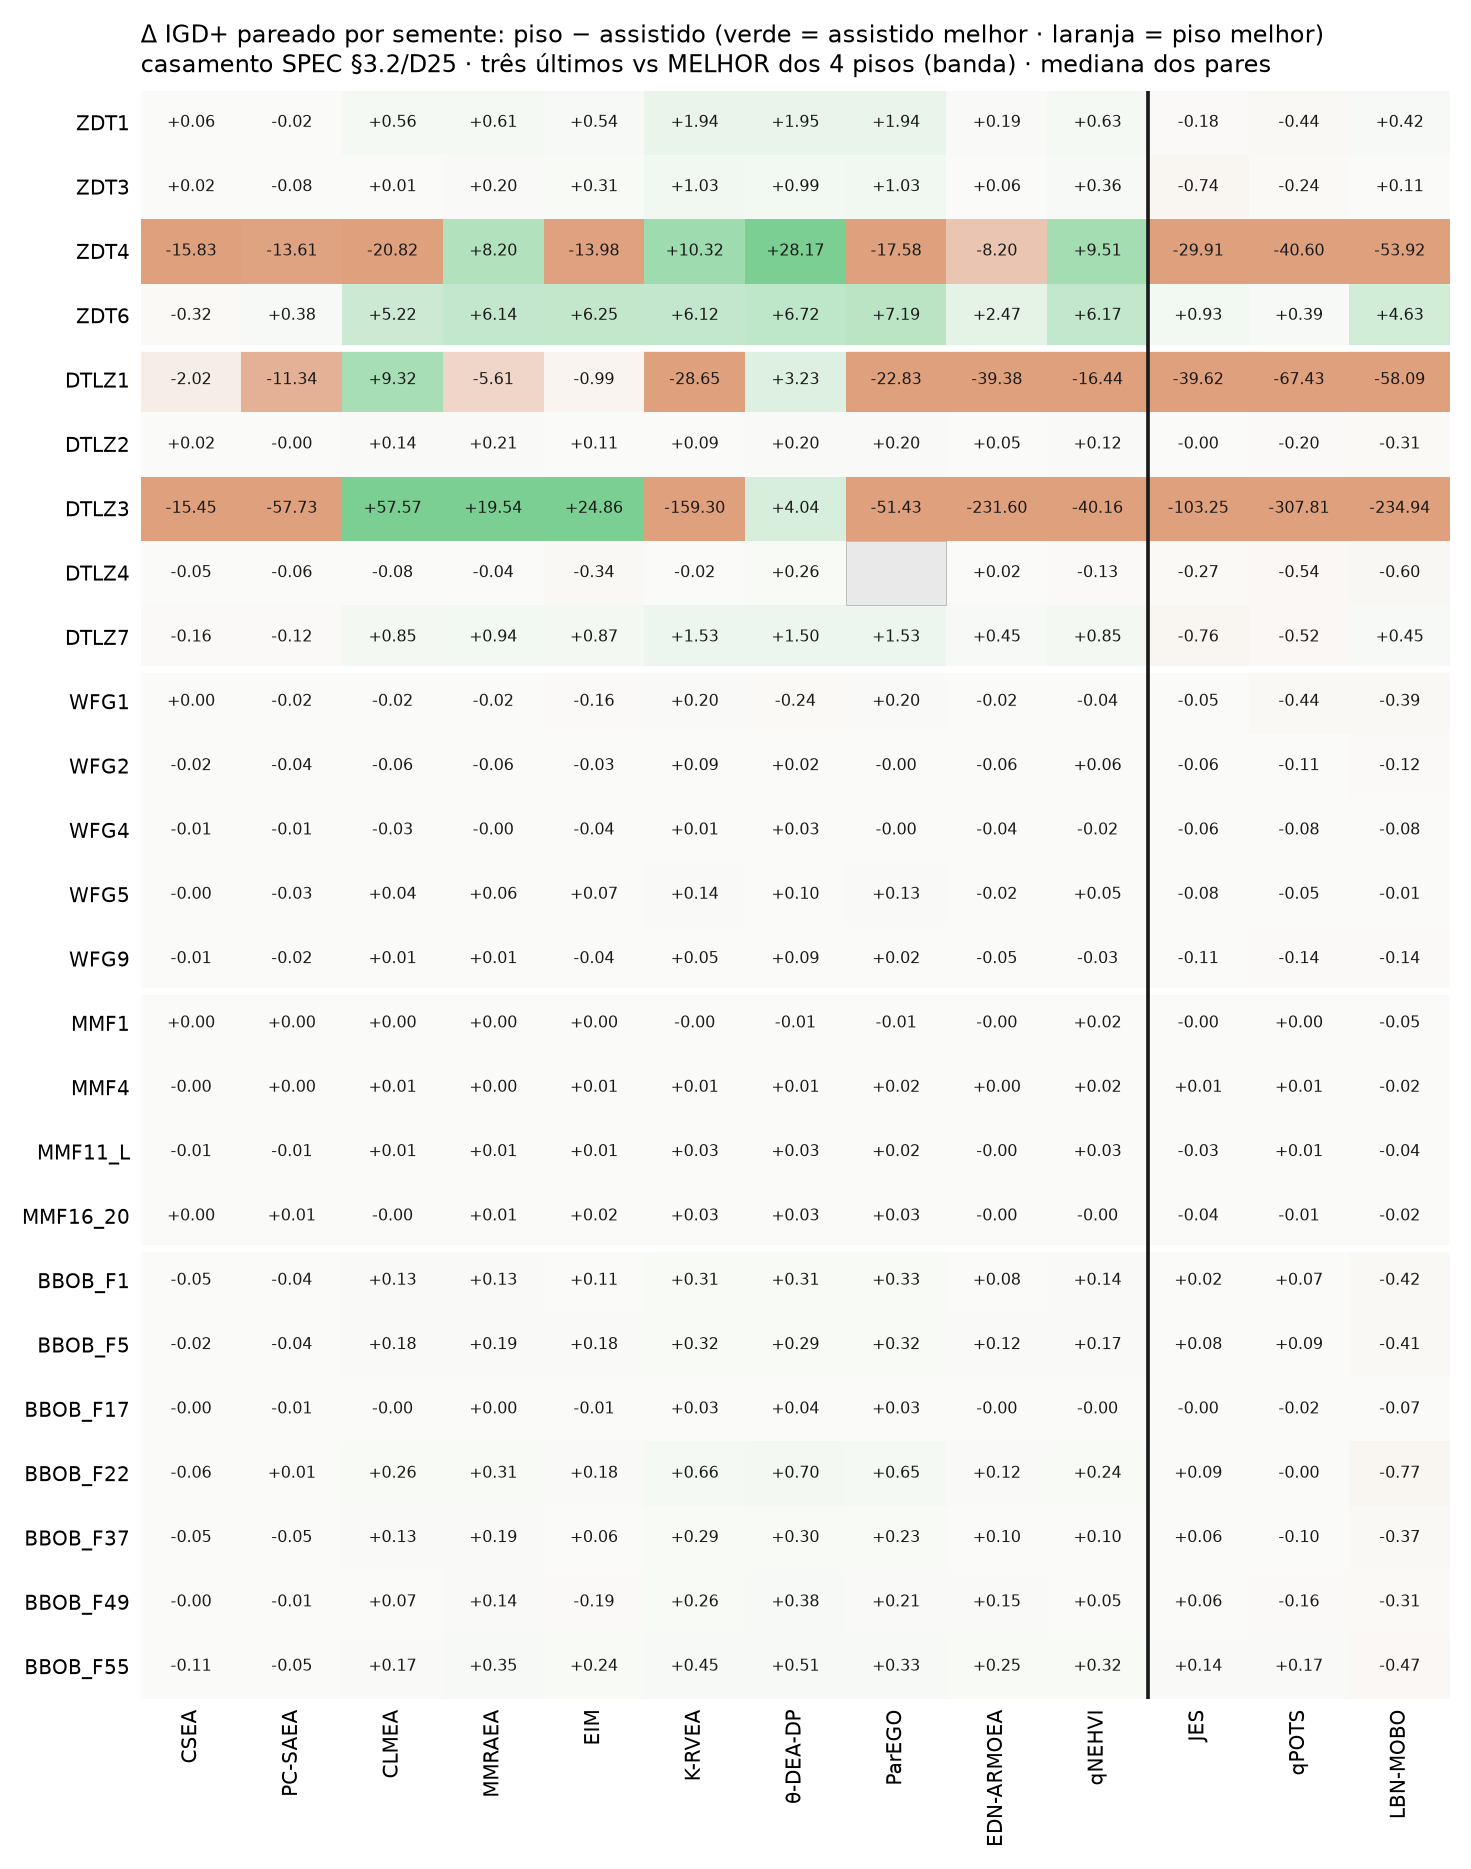

In [ ]:
SINTS = PROBLEMAS[:25]
SA = [a for a in ONLINE if a in PISO_DE] + BANDA
D = pd.DataFrame(index=SINTS, columns=SA, dtype=float)
PLACAR = {}
for a in SA:
    vit = der = 0
    sa_all = on[on.alg == a]
    for p in SINTS:
        sa = sa_all[sa_all.problema == p][["semente", "igd_plus"]].dropna()
        if a in PISO_DE:
            pi = on[(on.alg == PISO_DE[a]) & (on.problema == p)][["semente", "igd_plus"]].dropna()
            j = sa.merge(pi, on="semente", suffixes=("_sa", "_pi"))
        else:                                     # banda: contra o MELHOR dos 4 (D25)
            best = (on[(on.alg.isin(PISOS)) & (on.problema == p)]
                    .groupby("semente").igd_plus.min().rename("igd_plus_pi").reset_index())
            j = sa.rename(columns={"igd_plus": "igd_plus_sa"}).merge(best, on="semente")
        if len(j) >= 5:
            D.loc[p, a] = float((j.igd_plus_pi - j.igd_plus_sa).median())
            vit += D.loc[p, a] > 0; der += D.loc[p, a] < 0
    PLACAR[a] = (int(vit), int(der))

lim = float(np.nanpercentile(np.abs(D.values.astype(float)), 92))
fig, ax = plt.subplots(figsize=(6.8, 8.6))
V = D.values.astype(float)
ax.imshow(np.ma.masked_invalid(np.clip(V, -lim, lim)), cmap=DIVERG, vmin=-lim,
          vmax=lim, aspect="auto")
for i in range(V.shape[0]):
    for j in range(V.shape[1]):
        if np.isnan(V[i, j]):
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, color="#e9e9e9",
                                       hatch="///", ec="#bbbbbb", lw=.3))
        else:
            ax.text(j, i, f"{V[i, j]:+.2f}", ha="center", va="center", fontsize=5.2,
                    color="#1a1a1a")
ax.set_xticks(range(len(SA)))
ax.set_xticklabels([NOME[a] for a in SA], rotation=90, fontsize=6.5)
ax.set_yticks(range(len(SINTS)))
ax.set_yticklabels(SINTS, fontsize=6.5)
for s in sorted(SEPARA_APOS - {24}):
    ax.axhline(s + .5, color="white", lw=2.2)
ax.axvline(9.5, color="#1a1a1a", lw=1.2)
ax.set_title("Δ IGD+ pareado por semente: piso − assistido (verde = assistido melhor · laranja = piso melhor)\n"
             "casamento SPEC §3.2/D25 · três últimos vs MELHOR dos 4 pisos (banda) · mediana dos pares",
             fontsize=8, loc="left")
ax.tick_params(length=0)
[sp.set_visible(False) for sp in ax.spines.values()]
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"fig53_sa_vs_pisos.{ext}"), dpi=220,
                bbox_inches="tight")
plt.close(fig)
EMBED_PNG = [os.path.join(FIGDIR, "fig53_sa_vs_pisos.png")]
print("placar por algoritmo (problemas em que o assistido vence × perde do piso, IGD+):")
for a in SA:
    ref = NOME[PISO_DE[a]] if a in PISO_DE else "melhor dos 4"
    print(f"  {NOME[a]:12s} vs {ref:12s}  {PLACAR[a][0]:2d} × {PLACAR[a][1]:2d}")


## §6 · O regime offline e a ablação exata do σ (fig. 5.4)

**Objetivo.** O contraste mais cirúrgico da bateria: **Prob-MOEA/D × MOEA/D-média**
diferem SOMENTE no uso do desvio-padrão do modelo (mesmo dataset por semente,
mesmo surrogate GP, mesma maquinaria de busca — D90/§10). Qualquer diferença
pareada mede, isoladamente, o valor de usar a incerteza. IBEA-MS aparece como
`final_ausente` até a escalação F30 da ⑦ ser resolvida pelo autor.

ablação exata do σ (Prob-MOEA/D × MOEA/D-média, Δ IGD+ pareado; >0 = usar σ ajudou):
  σ ajuda em 15 de 25 problemas; piores/melhores casos:
    ZDT6       -1.2489
    ZDT1       -0.8289
    DTLZ7      -0.5604
    ZDT4       +43.1074
    DTLZ3      +48.9558
    DTLZ1      +55.9563
resumo salvo em data/analysis_cache/resumo_analises_2026-08-17.json


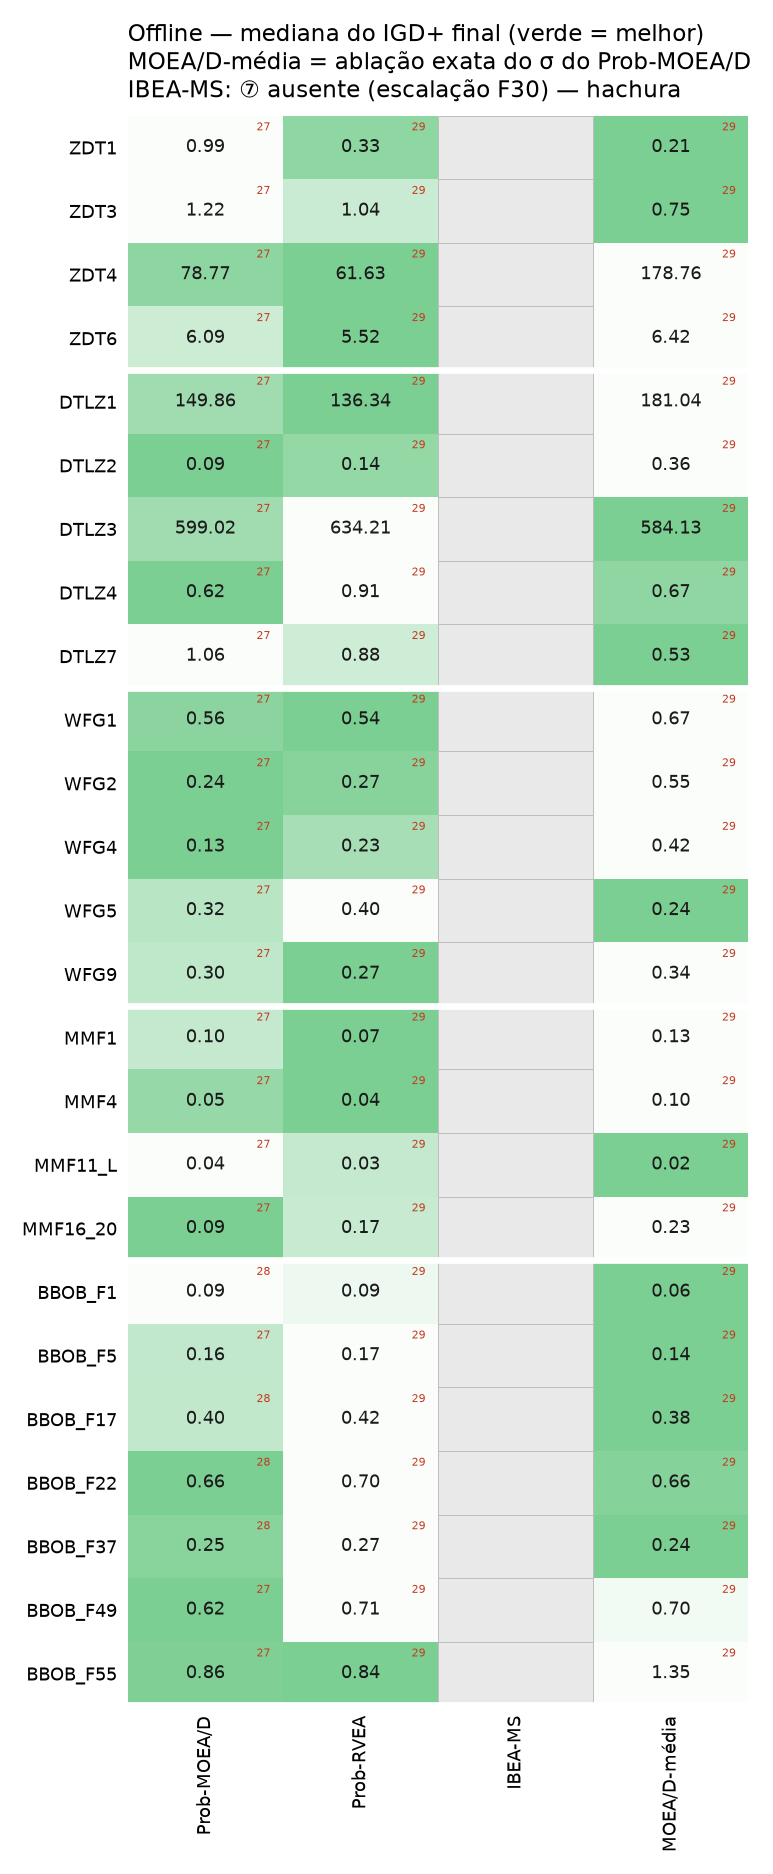

In [ ]:
SINTS = PROBLEMAS[:25]
medo, nseo = medianas(off, "igd_plus", OFFLINE, SINTS)
fig, ax = plt.subplots(figsize=(3.6, 8.6))
heat(ax, medo, nseo, VERDE, True, fs=5.8)
ax.set_title("Offline — mediana do IGD+ final (verde = melhor)\n"
             "MOEA/D-média = ablação exata do σ do Prob-MOEA/D\n"
             "IBEA-MS: ⑦ ausente (escalação F30) — hachura",
             fontsize=7.5, loc="left")
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"fig54_offline.{ext}"), dpi=220,
                bbox_inches="tight")
plt.close(fig)
EMBED_PNG = [os.path.join(FIGDIR, "fig54_offline.png")]

ABL = {}
for p in SINTS:
    s1 = off[(off.alg == "b5m") & (off.problema == p)][["semente", "igd_plus"]].dropna()
    s0 = off[(off.alg == "moead_media") & (off.problema == p)][["semente", "igd_plus"]].dropna()
    j = s1.merge(s0, on="semente", suffixes=("_sigma", "_media"))
    if len(j) >= 5:
        ABL[p] = float((j.igd_plus_media - j.igd_plus_sigma).median())
pos = sum(1 for v in ABL.values() if v > 0)
print(f"ablação exata do σ (Prob-MOEA/D × MOEA/D-média, Δ IGD+ pareado; >0 = usar σ ajudou):")
print(f"  σ ajuda em {pos} de {len(ABL)} problemas; piores/melhores casos:")
for p, v in sorted(ABL.items(), key=lambda kv: kv[1]):
    if p in [k for k, _ in sorted(ABL.items(), key=lambda kv: kv[1])[:3]] or \
       p in [k for k, _ in sorted(ABL.items(), key=lambda kv: kv[1])[-3:]]:
        print(f"    {p:10s} {v:+.4f}")

resumo = {"snapshot": "2026-08-17",
          "placar_sa_vs_piso": {NOME[a]: PLACAR[a] for a in PLACAR},
          "ablacao_b5m_vs_media": ABL,
          "rank_medio_igdp_online": json.loads(
              MED_IGDP.rank(axis=1).mean().sort_values().round(3).rename(index=NOME).to_json())}
with open(os.path.join(CACHE, "resumo_analises_2026-08-17.json"), "w") as f:
    json.dump(resumo, f, ensure_ascii=False, indent=1)
print("resumo salvo em data/analysis_cache/resumo_analises_2026-08-17.json")


## §7 · Conferências desta execução

1. o gate D92 (§2) passou na âncora analítica;
2. contra-cálculo INDEPENDENTE do HV (Monte Carlo, 200k pontos) numa amostra
   de células — caminho diferente do box-decomposition do pymoo;
3. `avisos_regua` — furos TOLERADOS da régua (arredondamento declarado da S.5,
   três ordens de grandeza abaixo do corte do guard, T15.13b).

In [ ]:
rng = np.random.default_rng(4242)
amostra = ok[(ok.exp == "main") & (ok.problema.isin(["ZDT1", "DTLZ2", "WFG4", "BBOB_F5"]))].sample(6, random_state=42)
piores = []
for _, r in amostra.iterrows():
    f = glob.glob(os.path.join(CORPUS, r.alg, r.problema, str(r.semente), "*__real.parquet"))[0]
    t = pq.read_table(f)
    fc = sorted([c for c in t.column_names if re.fullmatch(r"f\d+", c)], key=lambda c: int(c[1:]))
    F = np.column_stack([np.asarray(t.column(c), float) for c in fc])
    ideal, nadir = metrics.reference_bounds(r.problema)
    A = metrics.normalize(metrics.nondominated_front(F), ideal, nadir)
    M = A.shape[1]
    U = rng.random((200_000, M)) * metrics.HV_REF_COORD
    dom = np.zeros(len(U), bool)
    for a in A:
        dom |= (U >= a).all(axis=1)
    hv_mc = dom.mean() * metrics.HV_REF_COORD ** M
    piores.append(abs(hv_mc - r.hv))
    print(f"{r.alg:12s} {r.problema:9s} s{int(r.semente):2d}  HV oficial {r.hv:.4f} · MC {hv_mc:.4f} · |Δ| {abs(hv_mc-r.hv):.4f}")
assert max(piores) < 0.01, "contra-cálculo MC divergiu do HV oficial"
print("contra-cálculo MC: OK (|Δ| máx = %.4f, dentro do erro de amostragem)" % max(piores))
print("avisos_regua (furos tolerados, T15.13b):", {k: (int(v[0]), round(float(v[1]), 6)) for k, v in metrics.avisos_regua.items()} or "— (ledger do processo principal; os furos conhecidos são ZDT6/MMF4/MMF1, arredondamento declarado)")

c262         WFG4      s15  HV oficial 0.2819 · MC 0.2806 · |Δ| 0.0012
nsga2        WFG4      s22  HV oficial 0.3222 · MC 0.3226 · |Δ| 0.0004
smsemoa      DTLZ2     s25  HV oficial 0.4188 · MC 0.4209 · |Δ| 0.0021
c238         DTLZ2     s 7  HV oficial 0.4311 · MC 0.4324 · |Δ| 0.0014
b4           ZDT1      s 7  HV oficial 0.1365 · MC 0.1356 · |Δ| 0.0009
c141         BBOB_F5   s 2  HV oficial 0.8830 · MC 0.8815 · |Δ| 0.0016
contra-cálculo MC: OK (|Δ| máx = 0.0021, dentro do erro de amostragem)
avisos_regua (furos tolerados, T15.13b): — (ledger do processo principal; os furos conhecidos são ZDT6/MMF4/MMF1, arredondamento declarado)


## §8 · O que este notebook ainda NÃO faz (fila declarada)

1. **Escadinhas por característica (§5.3 da dissertação)** — exige o
   congelamento do corpus + a matriz `characteristics.csv` re-derivada (D98).
2. **Análise da sonda (σ reportado × erro real)** — camada ③ dos volumosos
   mora no bucket; baixar antes (censo 403 pendente, escalação F30).
3. **Testes estatísticos (§14: Friedman/Nemenyi, signed-rank pareado,
   bayesiano)** — decisão de família/multiplicidade é do AUTOR (D100).
4. **DDMOP7 fase 2** — régua pooled pós-hoc (D102.3) e re-execução da §12.
5. **Trajetórias (métrica × FE)** e attainment (D52) — próxima leva.